<a href="https://colab.research.google.com/github/febamv-boop/nittygritty/blob/main/Age_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
###Importing necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings, os, cv2, random
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, BatchNormalization, GlobalAveragePooling2D
from keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from tensorflow.keras.utils import plot_model, to_categorical
from tqdm.notebook import tqdm
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
### Mounting Drive to read the label file and image dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/Case studies/2. Age Detection/train.csv'

df = pd.read_csv(file_path)
print(df.head())

          ID   Class
0    377.jpg  MIDDLE
1  17814.jpg   YOUNG
2  21283.jpg  MIDDLE
3  16496.jpg   YOUNG
4   4487.jpg  MIDDLE


In [ ]:
df.Class.value_counts()

,count
Class,
MIDDLE,10804
YOUNG,6706
OLD,2396


#### Data Exploration

In [ ]:
df.shape

(19906, 2)

In [ ]:
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['Class']
)

In [ ]:
y_test=val_df['Class']
y_test

,Class
18742,MIDDLE
11487,YOUNG
7065,MIDDLE
6808,OLD
4025,YOUNG
...,...
17975,YOUNG
19445,OLD
9223,OLD
3169,MIDDLE


In [ ]:
# Data Preparation
img_dir = '/content/drive/MyDrive/Case studies/2. Age Detection/Train'

# Augmentation for Training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Rescaling for Validation
val_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# Training Generator
train_ds = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=img_dir,
    x_col="ID",
    y_col="Class",
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical"
)

# Validation Generator
val_ds = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=img_dir,
    x_col="ID",
    y_col="Class",
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 15924 validated image filenames belonging to 3 classes.
Found 3982 validated image filenames belonging to 3 classes.


In [ ]:
# Get the number of classes from the dataset
num_classes = len(train_ds.class_indices)
print(f"Number of classes: {num_classes}")

Number of classes: 3


In [ ]:
train_df['Class'].value_counts()

,count
Class,
MIDDLE,8643
YOUNG,5364
OLD,1917


In [ ]:
# Solving class imbalance by oversampling
class_to_index = train_ds.class_indices

# Create a copy of train_df to add encoded class labels
train_df_with_encoded_class = train_df.copy()
train_df_with_encoded_class['Class_Encoded'] = train_df_with_encoded_class['Class'].map(class_to_index)

# Separate DataFrames for each class using boolean indexing
class_0_df = train_df_with_encoded_class[train_df_with_encoded_class['Class_Encoded'] == 0]
class_1_df = train_df_with_encoded_class[train_df_with_encoded_class['Class_Encoded'] == 1]
class_2_df = train_df_with_encoded_class[train_df_with_encoded_class['Class_Encoded'] == 2]


def create_tf_dataset(df):
    dataset = tf.data.Dataset.from_tensor_slices((df['ID'].values, df['Class_Encoded'].values))

    # Function to load and preprocess images
    def load_and_preprocess_image(image_id, label):
        img_path = tf.strings.join([img_dir, "/", image_id])
        img = tf.io.read_file(img_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [128, 128])
        img = img / 255.0
        label = tf.one_hot(label, num_classes)
        return img, label

    return dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

class_0_ds = create_tf_dataset(class_0_df)
class_1_ds = create_tf_dataset(class_1_df)
class_2_ds = create_tf_dataset(class_2_df)

In [ ]:
class_0_ds = class_0_ds.repeat()
class_1_ds = class_1_ds.repeat()
class_2_ds = class_2_ds.repeat()

In [ ]:
bal_train_ds = tf.data.Dataset.sample_from_datasets(
    [class_0_ds, class_1_ds, class_2_ds],
    weights=[0.33, 0.33, 0.34]
)

In [ ]:

# Define data augmentation layers to apply on the fly
data_augmentation_layers = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal"),
  tf.keras.layers.RandomRotation(0.1),
  tf.keras.layers.RandomZoom(0.1),
  tf.keras.layers.RandomTranslation(0.1, 0.1)
])

# Map the augmentation layers to the training dataset and optimize pipeline
def apply_augmentation(image, label):
    return data_augmentation_layers(image, training=True), label

In [ ]:
bal_train_ds = bal_train_ds.map(
    apply_augmentation,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [ ]:
bal_train_ds = (
    bal_train_ds
    .shuffle(1000)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

### Model Training & Evaluation

In [ ]:

# Model Architecture
model = Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(128, 128, 3)),

    # First block
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Second block - increasing filters
    tf.keras.layers.SeparableConv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Third block
    tf.keras.layers.SeparableConv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Final feature extraction
    tf.keras.layers.SeparableConv2D(256, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    GlobalAveragePooling2D(),

    # Classifier
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(3, activation='softmax') # Fixed to 3 classes
])

In [ ]:
# Callbacks
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_accuracy', mode='max', patience=20, restore_best_weights=True, start_from_epoch=5, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.1, mode='max', patience=10, min_lr=1e-6, verbose=1),
    TensorBoard(log_dir='./', histogram_freq=1, write_graph=True, embeddings_freq=1, update_freq='epoch'),
    ModelCheckpoint(filepath='facial_age_detection.keras', monitor='val_accuracy', save_best_only=True, mode='max', save_freq='epoch', verbose=1)
]

In [ ]:
# Fitting the model

train_size = 15506
batch_size = 32
epochs=25
history = model.fit(
    bal_train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=callbacks,
    steps_per_epoch=(train_size//batch_size)
   )

Epoch 1/25
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4634 - loss: 1.1350
Epoch 1: val_accuracy improved from -inf to 0.12029, saving model to facial_age_detection.keras
484/484 ━━━━━━━━━━━━━━━━━━━━ 3306s 6s/step - accuracy: 0.4635 - loss: 1.1349 - val_accuracy: 0.1203 - val_loss: 2.4217 - learning_rate: 0.0010
Epoch 2/25
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5801 - loss: 0.9368
Epoch 2: val_accuracy improved from 0.12029 to 0.58061, saving model to facial_age_detection.keras
484/484 ━━━━━━━━━━━━━━━━━━━━ 795s 2s/step - accuracy: 0.5801 - loss: 0.9367 - val_accuracy: 0.5806 - val_loss: 0.9385 - learning_rate: 0.0010
Epoch 3/25
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6102 - loss: 0.8809
Epoch 3: val_accuracy did not improve from 0.58061
484/484 ━━━━━━━━━━━━━━━━━━━━ 568s 1s/step - accuracy: 0.6102 - loss: 0.8809 - val_accuracy: 0.3370 - val_loss: 16.3784 - learning_rate: 0.0010
Epoch 4/25
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6302 -

In [ ]:
### Predicting classes for train
train_eval_datagen = ImageDataGenerator(rescale=1./255)

train_eval_ds = train_eval_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=img_dir,
    x_col="ID",
    y_col="Class",
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

# Get predictions for the training set
train_predictions = model.predict(train_eval_ds)
train_predicted_classes = np.argmax(train_predictions, axis=-1)

Found 15924 validated image filenames belonging to 3 classes.
498/498 ━━━━━━━━━━━━━━━━━━━━ 146s 293ms/step


In [ ]:
# Get predictions for the validation set
val_predictions = model.predict(val_ds)
predicted_classes = np.argmax(val_predictions, axis=-1)

125/125 ━━━━━━━━━━━━━━━━━━━━ 32s 259ms/step


Confusion Matrix for Train:
[[6078 1002 1563]
 [ 147 1667  103]
 [ 453  163 4748]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      8643
           1       0.59      0.87      0.70      1917
           2       0.74      0.89      0.81      5364

    accuracy                           0.78     15924
   macro avg       0.75      0.82      0.77     15924
weighted avg       0.81      0.78      0.79     15924



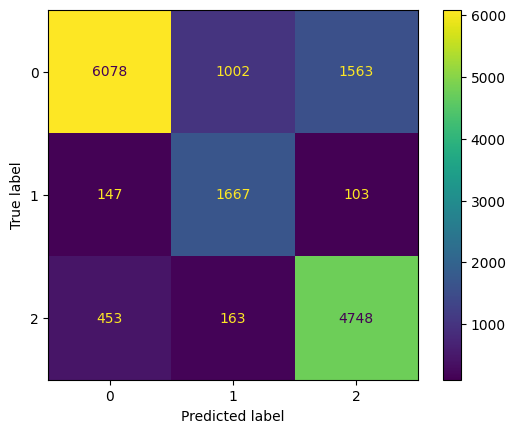

In [ ]:
print("Confusion Matrix for Train:")
print(confusion_matrix(train_eval_ds.classes, train_predicted_classes))
print("Classification Report:")
print(classification_report(train_eval_ds.classes, train_predicted_classes))
ConfusionMatrixDisplay.from_predictions(train_eval_ds.classes, train_predicted_classes)
plt.show()

Confusion Matrix for Test:
[[1468  248  445]
 [  56  386   37]
 [ 107   50 1185]]
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.68      0.77      2161
           1       0.56      0.81      0.66       479
           2       0.71      0.88      0.79      1342

    accuracy                           0.76      3982
   macro avg       0.73      0.79      0.74      3982
weighted avg       0.80      0.76      0.77      3982



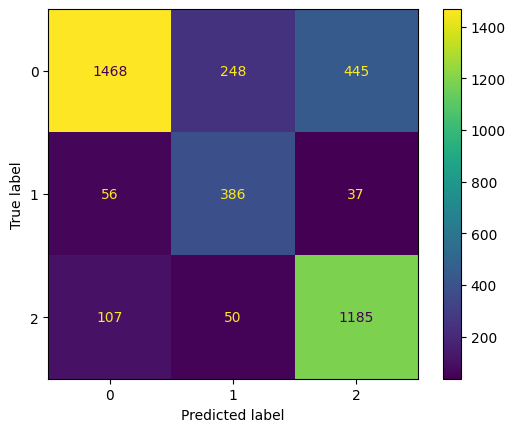

In [ ]:
print("Confusion Matrix for Test:")
print(confusion_matrix(val_ds.classes,predicted_classes))
print("Classification Report:")
print(classification_report(val_ds.classes,predicted_classes))
ConfusionMatrixDisplay.from_predictions(val_ds.classes,predicted_classes)
plt.show()

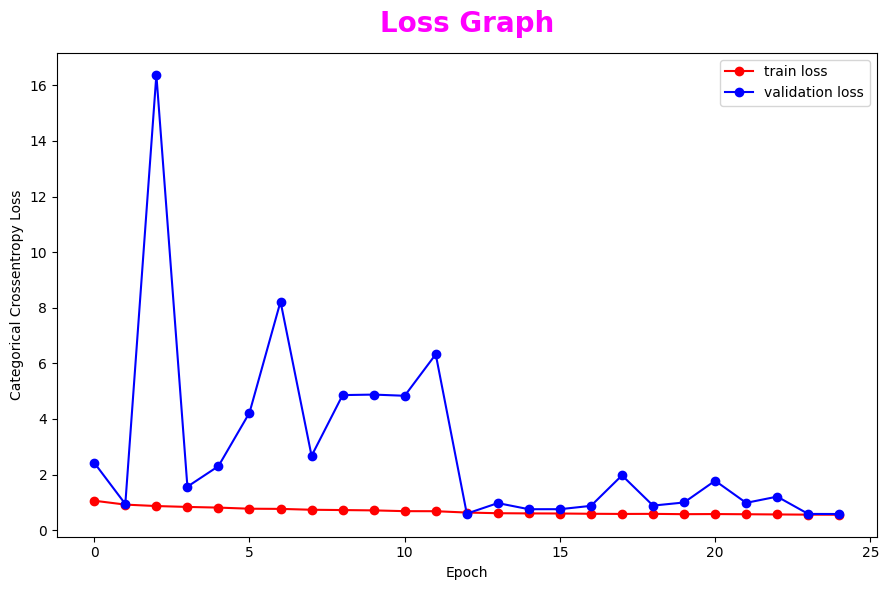

In [ ]:
plt.figure(figsize=(9,6))
plt.plot(history.history['loss'],'r',label='train loss',marker='o')
plt.plot(history.history['val_loss'],'b',label='validation loss',marker='o')
plt.title('Loss Graph', fontsize=20, pad=15, color='fuchsia', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Categorical Crossentropy Loss')
plt.legend()
plt.tight_layout()
plt.show();

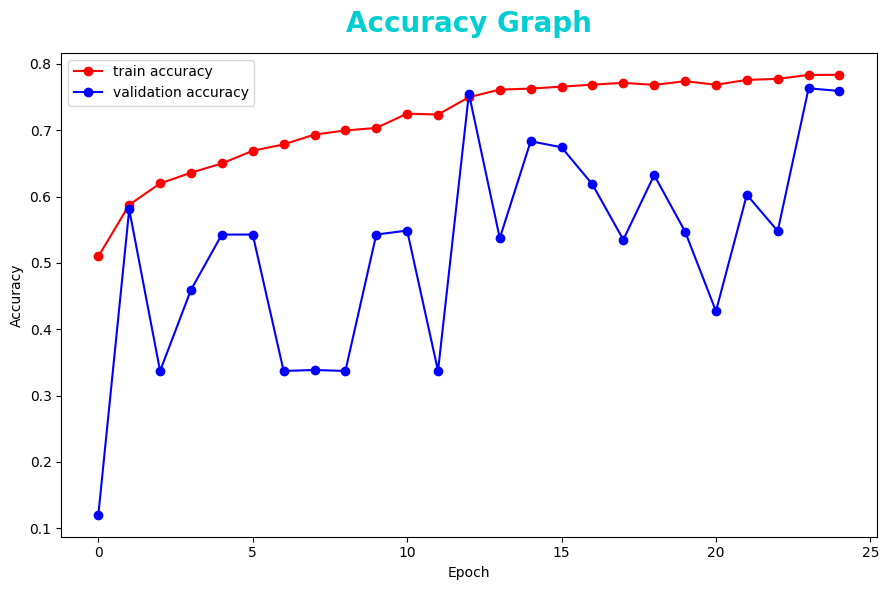

In [ ]:
plt.figure(figsize=(9,6))
plt.plot(history.history['accuracy'],'r',label='train accuracy',marker='o')
plt.plot(history.history['val_accuracy'],'b',label='validation accuracy',marker='o')
plt.title('Accuracy Graph', fontsize=20, pad=15, color='darkturquoise', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show();

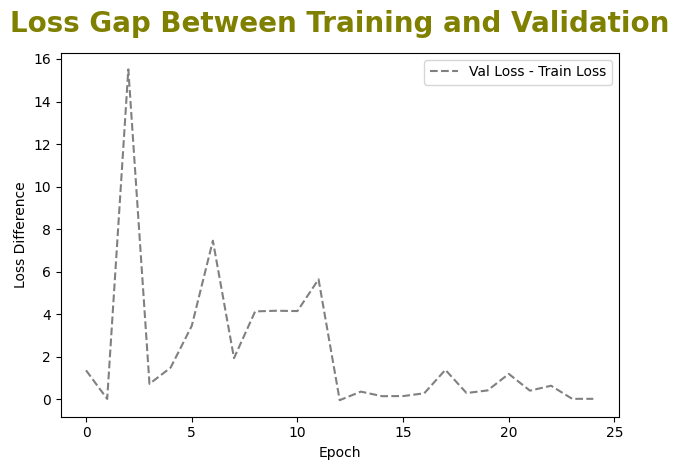

In [ ]:
# Checking for Overfitting/Underfitting
diff = np.array(history.history['val_loss']) - np.array(history.history['loss'])
plt.plot(diff, label='Val Loss - Train Loss', color='gray', linestyle='--')
plt.title('Loss Gap Between Training and Validation', fontsize=20, pad=15, color='olive', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss Difference')
plt.legend()
plt.tight_layout()
plt.show();

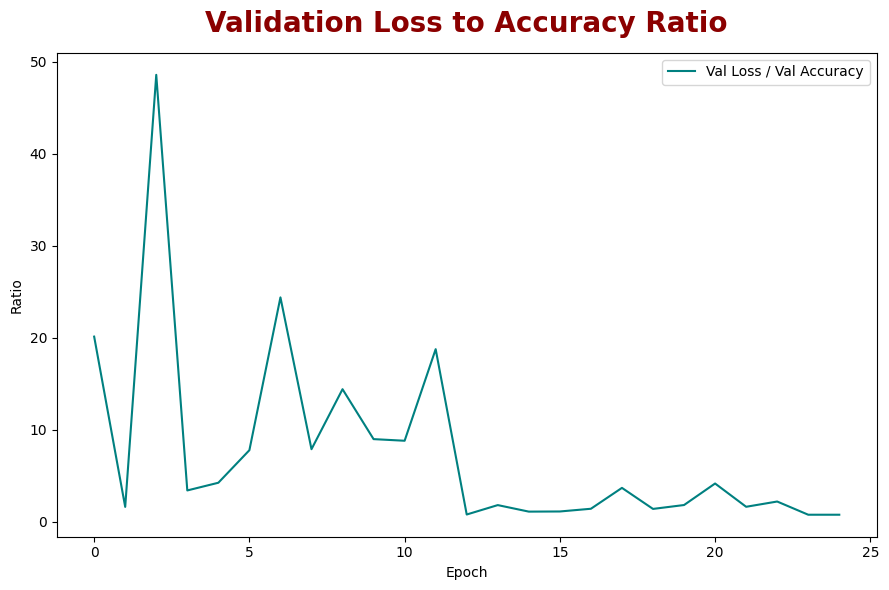

In [ ]:
# Validation Loss to Accuracy Ratio
ratio = np.array(history.history['val_loss']) / (np.array(history.history['val_accuracy']) + 1e-8)
plt.figure(figsize=(9,6))
plt.plot(ratio, label='Val Loss / Val Accuracy', color='teal')
plt.title('Validation Loss to Accuracy Ratio', fontsize=20, pad=15, color='darkred', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Ratio')
plt.legend()
plt.tight_layout()
plt.show()

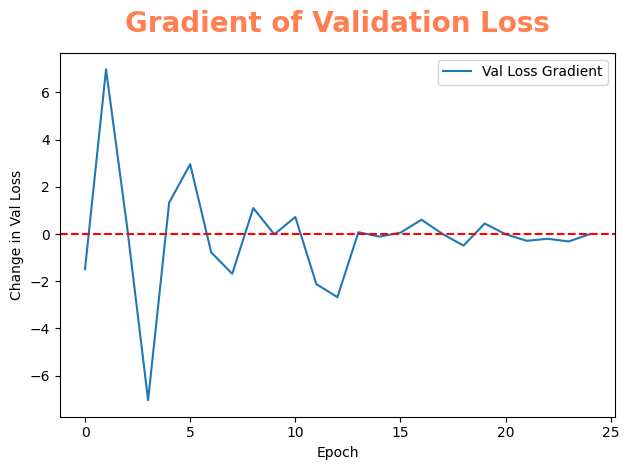

In [ ]:
# Convergence Check
loss_grad = np.gradient(history.history['val_loss'])
plt.plot(loss_grad, label='Val Loss Gradient')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Gradient of Validation Loss', fontsize=20, pad=15, color='coral', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Change in Val Loss')
plt.legend()
plt.tight_layout()
plt.show();

In [ ]:
### Printing the accuracy and loss for validation set
loss, acc = model.evaluate(val_ds)
print(f"Test Loss: {loss:.3f}")
print(f"Test Accuracy: {acc:.2f}")

125/125 ━━━━━━━━━━━━━━━━━━━━ 32s 256ms/step - accuracy: 0.7564 - loss: 0.5914
Test Loss: 0.583
Test Accuracy: 0.76
